In [41]:
import os 

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

import ipywidgets as widgets
from IPython.display import display

import json 

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
from src.model_selection import get_checkpoints, load_inference_models

EMBED_PATH = EMBEDS_DIR/ "category_head_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "category_head"

In [42]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [43]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [44]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [45]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

2.12.0+cu130
13.0
True
1
Device: cuda


In [46]:
DINO_DIR = MODELS / "dino_fine_tune"

dino_checkpoints = get_checkpoints(DINO_DIR)

print(f"Found {len(dino_checkpoints)} fine-tuned DINO checkpoints")

Found 1 fine-tuned DINO checkpoints


In [ ]:
dino_selector = widgets.Dropdown(
    options=[
        ("Select a DINO model", "UNSELECTED"),
        ("Pretrained DINOv2 ViT-S/14", None),
        *[
            (path.name, path)
            for path in dino_checkpoints
        ],
    ],
    value="UNSELECTED",
    description="DINO:",
    layout=widgets.Layout(width="800px")
)

confirm_button = widgets.Button(
    description="Confirm selection",
    button_style="success",
    layout=widgets.Layout(width="180px")
)

selection_output = widgets.Output()

selection_confirmed = False
selected_dino_path: Path | None | str = "UNSELECTED"

In [48]:
def confirm_selection(_: widgets.Button) -> None:
    global selection_confirmed
    global selected_dino_path

    selection_output.clear_output()

    with selection_output:
        if dino_selector.value == "UNSELECTED":
            print("Select a DINO model first.")
            return
        
        selected_dino_path = dino_selector.value
        selection_confirmed = True

        print("Selection confirmed.")

confirm_button.on_click(confirm_selection)

display(
    dino_selector,
    confirm_button,
    selection_output
)

Dropdown(description='DINO:', layout=Layout(width='800px'), options=(('Select a DINO model', 'UNSELECTED'), ('…

Button(button_style='success', description='Confirm selection', layout=Layout(width='180px'), style=ButtonStyl…

Output()

In [50]:
if not selection_confirmed:
    raise RuntimeError(
        "Execution stopped: choose a model, click "
        "'Confirm model selection', then run this cell "
        "or use 'Run All Below'."
    )

In [51]:
pipeline = load_inference_models(selected_dino_path, device=device)

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


Loading DINO: /home/ciaran/Projects/bursary/UL-Summer-Bursary-2026/models/dino_fine_tune/20260727_160258_dino_model.pt


In [52]:
inf_models = pipeline.models

print(
    f"Loaded DINO pipeline containing "
    f"{len(inf_models)} model(s)"
)

Loaded DINO pipeline containing 1 model(s)


In [53]:
%load_ext autoreload
%autoreload 0

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, train_one_epoch, evaluate

from src.fine_tune.losses.category_head.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.5
}

NOTES = [
    "Removed chance for horizontal swapping in transforms as thats not a good case for some categories(metal-nut) where horizontal flip is actually an anomaly",
    "Test for if the note display thing works as intended"
]

In [55]:
SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device.type == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = "model.pt"

In [56]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 256,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    },
    "parent_models" : {
        "dino": str(pipeline.dino_path)
    }
}

In [57]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [58]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [59]:
step_display = display(
    pd.DataFrame(),
    display_id=True
)

epoch_display = display(
    pd.DataFrame(),
    display_id=True
)

""


""


In [60]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:
    for epoch in tqdm(range(EPOCHS)):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, inf_models)
        val_loss = evaluate(model, val_loader, criterion, device, inf_models)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ) + "\n")

finally:
    if best_state is not None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        EXP_DIR = MODEL_DIR / timestamp
        os.makedirs(EXP_DIR, exist_ok=False)

        checkpoint = {
            "model_state_dict" : best_state,
            "parameters" : MODEL_INFO["parameters"],
            "parent_models" : MODEL_INFO["parent_models"]
        }

        torch.save(checkpoint, EXP_DIR / MODEL_NAME)

        with open(EXP_DIR / "metadata.json", "w") as f:
            json.dump(MODEL_INFO, f, indent=4)

        results.to_csv(EXP_DIR / "train_history.csv", index=False)
        
        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

same=0.9759, different=0.0022, gap=0.9737
same=0.9742, different=-0.0147, gap=0.9889
same=0.9748, different=-0.0191, gap=0.9940
same=0.9754, different=-0.0178, gap=0.9933
same=0.9749, different=-0.0145, gap=0.9894
same=0.9765, different=-0.0110, gap=0.9875
same=0.9743, different=-0.0087, gap=0.9831
same=0.9764, different=-0.0063, gap=0.9827
same=0.9767, different=-0.0072, gap=0.9839
same=0.9772, different=-0.0077, gap=0.9849
same=0.9757, different=-0.0086, gap=0.9844
same=0.9753, different=-0.0095, gap=0.9848
same=0.9774, different=-0.0114, gap=0.9888
same=0.9763, different=-0.0116, gap=0.9879
same=0.9784, different=-0.0121, gap=0.9906
same=0.9782, different=-0.0121, gap=0.9903
same=0.9769, different=-0.0127, gap=0.9896
same=0.9767, different=-0.0119, gap=0.9886
same=0.9767, different=-0.0114, gap=0.9881
same=0.9782, different=-0.0116, gap=0.9898
same=0.9762, different=-0.0113, gap=0.9875
same=0.9781, different=-0.0106, gap=0.9887
same=0.9764, different=-0.0098, gap=0.9863
same=0.9771,

KeyboardInterrupt: 

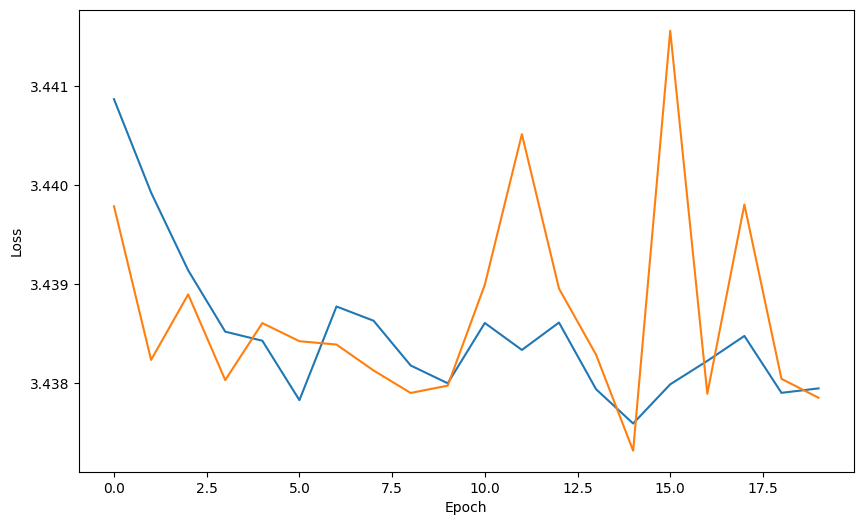

In [ ]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()